Analyze time-series fluorescence data from PURE experiments.

## Setup 

In [1]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

In [3]:
import os
os.chdir('/Volumes/sharon/bnext/experiments/20260318-DiscoveryPlate-ARIA-R1')

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/sharon/bnext/experiments/20260318-DiscoveryPlate-ARIA-R1'

## Load Data

In [2]:
labcraft_platemap = pd.read_csv("experiment_setup/concentration_key_old.csv")
labcraft_platemap = labcraft_platemap.rename(columns={'Well ID': 'Well'})
labcraft_platemap = labcraft_platemap.set_index("Well")

samples = pd.read_csv("experiment_setup/samples_titration_LOCK.csv", index_col="Well")
samples["Type"] = "Sample"

In [3]:
labcraft_platemap.index.unique()

Index(['F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'G9', 'G10', 'G11',
       'G12', 'G13', 'G14', 'G15', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14',
       'H15', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'J9', 'J10',
       'J11', 'J12', 'J13', 'J14', 'J15'],
      dtype='object', name='Well')

In [4]:

labcraft_platemap.columns

Index(['[Amino Acids]_mM', '[ATP]_mM', '[Creatine phosphate]_mM', '[GTP]_mM',
       '[Magnesium acetate]_mM', '[Potassium glutamate]_mM', '[tRNA]_ug/uL',
       'Water_--'],
      dtype='object')

In [5]:
# samples = samples.reset_index()
samples.head()

,Name,[DNA] (nM),[PMix] (mg/mL),[Ribosome] (uM),[Magnesium acetate] (mM),[Creatine phosphate] (mM),[Potassium glutamate] (mM),[ATP] (mM),[GTP] (mM),[Amino Acids] (mM),...,[GTP] (mM) vol_to_pipette_ul,[Amino Acids] (mM) conc_to_add,[Amino Acids] (mM) vol_to_pipette_ul,[tRNA] (ug/uL) conc_to_add,[tRNA] (ug/uL) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type
Well,,,,,,,,,,,,,,,,,,,,,
J12,1,5,1.80,1.80,7.60,21.80,98.40,1.95,2.26,0.40,...,0.23,0.40,1.23,3.14,0.90,5.41,3.19,1.40,10.00,Sample
G9,2,5,1.80,1.80,1.00,60.00,40.00,3.04,1.40,0.29,...,0.14,0.29,0.89,2.34,0.67,5.41,2.77,1.83,10.00,Sample
J15,3,5,1.80,1.80,6.70,44.70,76.90,2.88,2.04,0.30,...,0.20,0.30,0.92,1.84,0.53,5.41,2.72,1.87,10.00,Sample
I11,4,5,1.80,1.80,7.70,60.00,41.50,2.63,2.52,0.40,...,0.25,0.40,1.23,2.43,0.69,5.41,3.24,1.36,10.00,Sample
I9,5,5,1.80,1.80,1.00,43.80,40.00,2.40,2.72,0.26,...,0.27,0.26,0.80,2.62,0.75,5.41,2.66,1.93,10.00,Sample


In [6]:
import re

# Generic rename: labcraft format "[Name]_unit" or "Name_unit" → "[Name] (unit)"
def _rename_labcraft_col(col):
    m = re.match(r'^(.+)_([^_]+)$', col)
    if m:
        name, unit = m.group(1), m.group(2)
        if unit != '--':
            return f"{name} ({unit})"
    return col

labcraft_platemap = labcraft_platemap.rename(columns=_rename_labcraft_col)

# --- Add base master mix contributions for all matching columns ---
base_mm = pd.read_csv("experiment_setup/base_master_mix_LOCK.csv", index_col="reagent")

def _col_to_reagent_key(col):
    """Convert '[Magnesium acetate] (mM)' → 'magnesium_acetate'"""
    name = re.sub(r'\s*\([^)]*\)', '', col).strip()  # remove (unit)
    name = re.sub(r'[\[\]]', '', name).strip()        # remove brackets
    return name.lower().replace(' ', '_')

for col in labcraft_platemap.select_dtypes('number').columns:
    key = _col_to_reagent_key(col)
    if key in base_mm.index:
        base_conc = base_mm.loc[key, 'base_conc']
        labcraft_platemap[col] += base_conc
        print(f"Added base_conc for '{col}': +{base_conc} {base_mm.loc[key, 'unit']}")

labcraft_platemap

,[Amino Acids] (mM),[ATP] (mM),[Creatine phosphate] (mM),[GTP] (mM),[Magnesium acetate] (mM),[Potassium glutamate] (mM),[tRNA] (ug/uL),Water_--
Well,,,,,,,,
F9,0.39,1.70,22.00,2.90,8.00,97.50,3.54,0.13
F10,0.31,2.90,34.00,1.90,21.00,97.50,2.90,0.14
F11,0.32,2.60,60.00,2.60,10.00,40.00,3.99,0.12
F12,0.36,2.30,60.00,2.10,25.00,97.50,3.50,0.09
F13,0.40,2.60,NaN,2.50,8.00,107.50,3.25,0.15
F14,0.30,1.90,24.00,2.30,4.00,82.50,3.96,0.16
F15,0.40,2.60,NaN,1.80,4.00,57.50,2.13,0.21
G9,0.29,3.00,60.00,1.40,1.00,40.00,2.35,0.19
G10,0.19,2.50,NaN,2.60,22.00,180.00,2.87,0.18


In [7]:
FACTOR_COLS = labcraft_platemap.columns[:-1]
FACTOR_COLS

Index(['[Amino Acids] (mM)', '[ATP] (mM)', '[Creatine phosphate] (mM)',
       '[GTP] (mM)', '[Magnesium acetate] (mM)', '[Potassium glutamate] (mM)',
       '[tRNA] (ug/uL)'],
      dtype='object')

In [11]:
!pwd

/data/bnext/experiments/20260318-DiscoveryPlate-ARIA-R1


In [8]:


# Overwrite common concentration columns in samples with labcraft_platemap values
# Use .update() so only matching well_ids are overwritten (no NaNs for missing wells)
common_cols = labcraft_platemap.columns.intersection(samples.columns).tolist()
samples.update(labcraft_platemap[common_cols])
print(f"Updated {len(common_cols)} columns in samples from labcraft_platemap: {common_cols}")
samples.head()

Updated 7 columns in samples from labcraft_platemap: ['[Amino Acids] (mM)', '[ATP] (mM)', '[Creatine phosphate] (mM)', '[GTP] (mM)', '[Magnesium acetate] (mM)', '[Potassium glutamate] (mM)', '[tRNA] (ug/uL)']


,Name,[DNA] (nM),[PMix] (mg/mL),[Ribosome] (uM),[Magnesium acetate] (mM),[Creatine phosphate] (mM),[Potassium glutamate] (mM),[ATP] (mM),[GTP] (mM),[Amino Acids] (mM),...,[GTP] (mM) vol_to_pipette_ul,[Amino Acids] (mM) conc_to_add,[Amino Acids] (mM) vol_to_pipette_ul,[tRNA] (ug/uL) conc_to_add,[tRNA] (ug/uL) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type
Well,,,,,,,,,,,,,,,,,,,,,
J12,1,5,1.80,1.80,8.00,22.00,97.50,1.90,2.30,0.40,...,0.23,0.40,1.23,3.14,0.90,5.41,3.19,1.40,10.00,Sample
G9,2,5,1.80,1.80,1.00,60.00,40.00,3.00,1.40,0.29,...,0.14,0.29,0.89,2.34,0.67,5.41,2.77,1.83,10.00,Sample
J15,3,5,1.80,1.80,7.00,45.00,77.50,2.90,2.00,0.30,...,0.20,0.30,0.92,1.84,0.53,5.41,2.72,1.87,10.00,Sample
I11,4,5,1.80,1.80,8.00,60.00,42.50,2.60,2.50,0.40,...,0.25,0.40,1.23,2.43,0.69,5.41,3.24,1.36,10.00,Sample
I9,5,5,1.80,1.80,1.00,44.00,40.00,2.40,2.70,0.26,...,0.27,0.26,0.80,2.62,0.75,5.41,2.66,1.93,10.00,Sample


In [9]:
# Add standard wells not in DOE samples
standards = pd.DataFrame([
    {"well_id": "K9", "Type": "Standard", "Name": "Standard"},
    {"well_id": "K10", "Type": "Standard", "Name": "Standard"},
     {"well_id": "K11", "Type": "Standard", "Name": "Standard"},
]).set_index("well_id")
samples = pd.concat([samples, standards])
samples["Well"] = samples.index

samples.to_csv("samples_final.csv")


In [10]:
samples.Well.unique()

array(['J12', 'G9', 'J15', 'I11', 'I9', 'J9', 'H13', 'G12', 'H11', 'I14',
       'F9', 'F12', 'I10', 'H12', 'G10', 'H15', 'J11', 'F14', 'H9', 'I15',
       'I12', 'J14', 'J13', 'H10', 'H14', 'I13', 'F11', 'G13', 'F15',
       'F10', 'G15', 'G14', 'J10', 'F13', 'G11', 'K9', 'K10', 'K11'],
      dtype=object)

In [11]:
# Specify file paths
data_file = "20260319-120157-cytation5-pure-timecourse-gfp-biotek-cdk.txt"
platemap_file = "samples_final.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()
# data["conditions"] = data.groupby(factors).ngroup()
# data["Name"] = data["conditions"]

# data = data[~data["Column"].isin([19])]

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Name,[DNA] (nM),...,[GTP] (mM) vol_to_pipette_ul,[Amino Acids] (mM) conc_to_add,[Amino Acids] (mM) vol_to_pipette_ul,[tRNA] (ug/uL) conc_to_add,[tRNA] (ug/uL) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type
0,0 days 00:00:22,F9,435,F,9,GFP-Gext,Plate 1,2026-03-19 12:02:56,11,5.00,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
1,0 days 00:05:22,F9,526,F,9,GFP-Gext,Plate 1,2026-03-19 12:07:56,11,5.00,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
2,0 days 00:10:22,F9,1211,F,9,GFP-Gext,Plate 1,2026-03-19 12:12:56,11,5.00,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
3,0 days 00:15:22,F9,4428,F,9,GFP-Gext,Plate 1,2026-03-19 12:17:56,11,5.00,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
4,0 days 00:20:22,F9,11206,F,9,GFP-Gext,Plate 1,2026-03-19 12:22:56,11,5.00,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample


In [12]:
data.to_csv("samples_final_with_data.csv")

## Plot Raw Curves

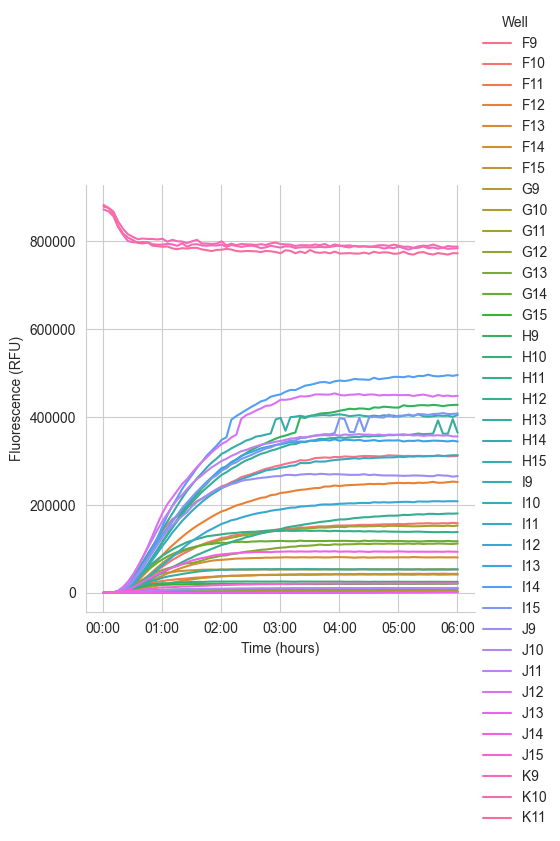

In [17]:
g = pr.plot_curves(data=data, hue="Well")#[data.Type == "Sample"]) #, hue="conditions")

In [18]:
data.Name.unique()

array(['11', '30', '27', '12', '34', '18', '29', '2', '15', '35', '8',
       '28', '32', '31', '19', '24', '9', '14', '7', '25', '16', '5',
       '13', '4', '21', '26', '10', '20', '6', '33', '17', '1', '23',
       '22', '3', 'Standard'], dtype=object)

In [19]:
data

,Time,Temperature,Well,Data,Row,Column,Read,Plate,Clock Time,Reader,...,[GTP] (mM) vol_to_pipette_ul,[Amino Acids] (mM) conc_to_add,[Amino Acids] (mM) vol_to_pipette_ul,[tRNA] (ug/uL) conc_to_add,[tRNA] (ug/uL) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type
0,0 days 00:00:22,27.70,F9,435,F,9,GFP-Gext,Plate 1,2026-03-19 12:02:56,Cytation5,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
1,0 days 00:05:22,33.80,F9,526,F,9,GFP-Gext,Plate 1,2026-03-19 12:07:56,Cytation5,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
2,0 days 00:10:22,37.00,F9,1211,F,9,GFP-Gext,Plate 1,2026-03-19 12:12:56,Cytation5,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
3,0 days 00:15:22,37.00,F9,4428,F,9,GFP-Gext,Plate 1,2026-03-19 12:17:56,Cytation5,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
4,0 days 00:20:22,37.00,F9,11206,F,9,GFP-Gext,Plate 1,2026-03-19 12:22:56,Cytation5,...,0.29,0.39,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2769,0 days 05:40:22,37.00,K11,773242,K,11,GFP-Gext,Plate 1,2026-03-19 17:42:56,Cytation5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard
2770,0 days 05:45:22,37.00,K11,771628,K,11,GFP-Gext,Plate 1,2026-03-19 17:47:56,Cytation5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard
2771,0 days 05:50:22,37.00,K11,769785,K,11,GFP-Gext,Plate 1,2026-03-19 17:52:56,Cytation5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard
2772,0 days 05:55:22,37.00,K11,773055,K,11,GFP-Gext,Plate 1,2026-03-19 17:57:56,Cytation5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard


## Normalize Data

In [20]:
data = pr.normalize_data_to_controls(data, ctrl_name = 'Standard')

Data Normalized to Standard in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

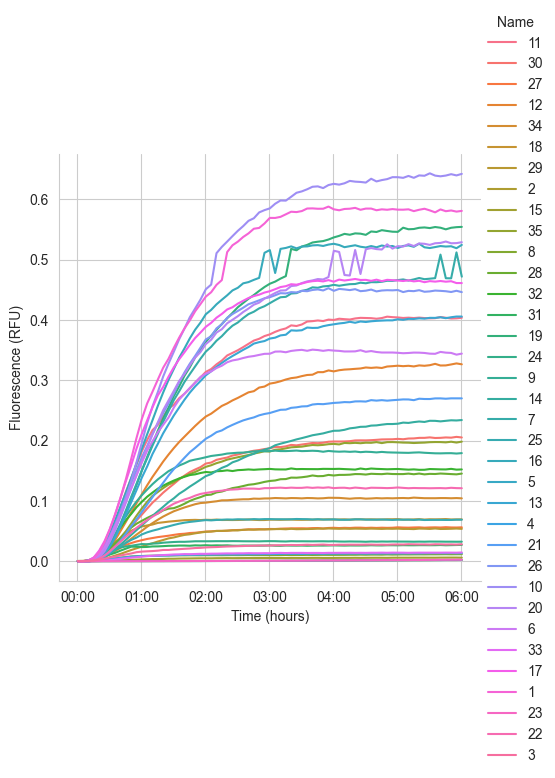

In [21]:
g = pr.plot_curves(data=data[data.Type == "Sample"])

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [22]:
data.columns

Index(['Time', 'Temperature', 'Well', 'Data', 'Row', 'Column', 'Read', 'Plate',
       'Clock Time', 'Reader', 'Name', '[DNA] (nM)', '[PMix] (mg/mL)',
       '[Ribosome] (uM)', '[Magnesium acetate] (mM)',
       '[Creatine phosphate] (mM)', '[Potassium glutamate] (mM)', '[ATP] (mM)',
       '[GTP] (mM)', '[Amino Acids] (mM)', '[tRNA] (ug/uL)', 'hepes mM',
       'ppk uM', 'polyphosphate mM', 'ctp mM', 'utp mM', 'tcep mM',
       'folinic_acid mM', 'spermidine mM', 'rnas_inh U/ml',
       '[Magnesium acetate] (mM) conc_to_add',
       '[Magnesium acetate] (mM) vol_to_pipette_ul',
       '[Creatine phosphate] (mM) conc_to_add',
       '[Creatine phosphate] (mM) vol_to_pipette_ul',
       '[Potassium glutamate] (mM) conc_to_add',
       '[Potassium glutamate] (mM) vol_to_pipette_ul',
       '[ATP] (mM) conc_to_add', '[ATP] (mM) vol_to_pipette_ul',
       '[GTP] (mM) conc_to_add', '[GTP] (mM) vol_to_pipette_ul',
       '[Amino Acids] (mM) conc_to_add',
       '[Amino Acids] (mM) vol_to_pip

In [23]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Well',  *FACTOR_COLS],  # Group by experimental condition
)
# kinetics = kinetics.reset_index()
kinetics.head()

Calculating Kinetics


Velocity  \
                                                                                                                                                                Time   
Well [Amino Acids] (mM) [ATP] (mM) [Creatine phosphate] (mM) [GTP] (mM) [Magnesium acetate] (mM) [Potassium glutamate] (mM) [tRNA] (ug/uL)                             
F9   0.39               1.70       22.00                     2.90       8.00                     97.50                      3.54           0 days 00:57:42.635813677   
F10  0.31               2.90       34.00                     1.90       21.00                    97.50                      2.90           0 days 01:02:50.784746528   
F11  0.32               2.60       60.00                     2.60       10.00                    40.00                      3.99           0 days 00:39:43.360498972   
F12  0.36               2.30       60.00                     2.10       25.00                    97.50                      3.50           0 days 01:05:14.263351818   
F13  0.40               2.60       0.00                      2.50       8.00                     107.50                     3.25           0 days 01:00:00.739639846   

                                                                                                                                                            \
                                                                                                                                           data_normalized   
Well [Amino Acids] (mM) [ATP] (mM) [Creatine phosphate] (mM) [GTP] (mM) [Magnesium acetate] (mM) [Potassium glutamate] (mM) [tRNA] (ug/uL)                   
F9   0.39               1.70       22.00                     2.90       8.00                     97.50                      3.54                      0.20   
F10  0.31               2.90       34.00                     1.90       21.00                    97.50                      2.90                      0.10   
F11  0.32               2.60       60.00                     2.60       10.00                    40.00                      3.99                      0.03   
F12  0.36               2.30       60.00                     2.10       25.00                    97.50                      3.50                      0.17   
F13  0.40               2.60       0.00                      2.50       8.00                     107.50                     3.25                      0.05   

                                                                                                                                                 \
                                                                                                                                            Max   
Well [Amino Acids] (mM) [ATP] (mM) [Creatine phosphate] (mM) [GTP] (mM) [Magnesium acetate] (mM) [Potassium glutamate] (mM) [tRNA] (ug/uL)        
F9   0.39               1.70       22.00                     2.90       8.00                     97.50                      3.54           0.21   
F10  0.31               2.90       34.00                     1.90       21.00                    97.50                      2.90           0.11   
F11  0.32               2.60       60.00                     2.60       10.00                    40.00                      3.99           0.05   
F12  0.36               2.30       60.00                     2.10       25.00                    97.50                      3.50           0.15   
F13  0.40               2.60       0.00                      2.50       8.00                     107.50                     3.25           0.08   

                                                                                                                                                                   Lag  \
                                                                                                                                                                  Time   
Well [Amino Acids] (mM) [ATP]

In [24]:
data.head()

,Time,Temperature,Well,Data,Row,Column,Read,Plate,Clock Time,Reader,...,[Amino Acids] (mM) vol_to_pipette_ul,[tRNA] (ug/uL) conc_to_add,[tRNA] (ug/uL) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type,ctrl_ints,data_normalized
0,0 days 00:00:22,27.70,F9,435,F,9,GFP-Gext,Plate 1,2026-03-19 12:02:56,Cytation5,...,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample,772485.58,0.00
1,0 days 00:05:22,33.80,F9,526,F,9,GFP-Gext,Plate 1,2026-03-19 12:07:56,Cytation5,...,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample,772485.58,0.00
2,0 days 00:10:22,37.00,F9,1211,F,9,GFP-Gext,Plate 1,2026-03-19 12:12:56,Cytation5,...,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample,772485.58,0.00
3,0 days 00:15:22,37.00,F9,4428,F,9,GFP-Gext,Plate 1,2026-03-19 12:17:56,Cytation5,...,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample,772485.58,0.01
4,0 days 00:20:22,37.00,F9,11206,F,9,GFP-Gext,Plate 1,2026-03-19 12:22:56,Cytation5,...,1.19,3.55,1.01,5.41,3.30,1.29,10.00,Sample,772485.58,0.01


## Visualize Fits on Individual Wells

In [25]:
# Plot kinetic fits 
# g = pr.plot_kinetics(data,  group_by=['Well', *FACTOR_COLS])

## Summary Plots

In [26]:
# pr.plot_summary(data)

In [27]:
responses = ["steady_state", "vmax", "lag_time_min"]

kin = kinetics.reset_index()
kin.columns = [
    "_".join([str(x).replace(" ", "_") for x in col if x])
    for col in kin.columns
]
factors = [str(x).replace(" ", "_") for x in FACTOR_COLS]
kin.head()

,Well,[Amino_Acids]_(mM),[ATP]_(mM),[Creatine_phosphate]_(mM),[GTP]_(mM),[Magnesium_acetate]_(mM),[Potassium_glutamate]_(mM),[tRNA]_(ug/uL),Velocity_Time,Velocity_data_normalized,Velocity_Max,Lag_Time,Lag_data_normalized,Steady_State_Time,Steady_State_data_normalized,Fit_params,Fit_R^2,Fit_drift,Fit_good_fit
0,F9,0.39,1.70,22.00,2.90,8.00,97.50,3.54,0 days 00:57:42.635813677,0.20,0.21,0 days 00:01:16.396357515,-0.01,0 days 02:20:47.923536436,0.37,"[0.3911673558071128, 2.126252468159096, 0.9618...",0.99,0.01,True
1,F10,0.31,2.90,34.00,1.90,21.00,97.50,2.90,0 days 01:02:50.784746528,0.10,0.11,0 days 00:09:17.193404538,-0.00,0 days 02:21:41.896550980,0.19,"[0.1964034979047539, 2.2404840052641704, 1.047...",1.00,0.01,True
2,F11,0.32,2.60,60.00,2.60,10.00,40.00,3.99,0 days 00:39:43.360498972,0.03,0.05,0 days 00:08:31.688212801,-0.00,0 days 01:25:38.872915356,0.05,"[0.05452717381062538, 3.846827276835713, 0.662...",0.99,0.00,True
3,F12,0.36,2.30,60.00,2.10,25.00,97.50,3.50,0 days 01:05:14.263351818,0.17,0.15,-1 days +23:59:46.779135965,-0.02,0 days 02:41:36.382158222,0.31,"[0.33039158548490144, 1.8332346117229594, 1.08...",1.00,0.01,True
4,F13,0.40,2.60,0.00,2.50,8.00,107.50,3.25,0 days 01:00:00.739639846,0.05,0.08,0 days 00:22:47.488211961,0.01,0 days 01:54:48.575915874,0.10,"[0.10447664877248576, 3.223998835432102, 1.000...",1.00,0.00,True


In [28]:
kin.columns

Index(['Well', '[Amino_Acids]_(mM)', '[ATP]_(mM)', '[Creatine_phosphate]_(mM)',
       '[GTP]_(mM)', '[Magnesium_acetate]_(mM)', '[Potassium_glutamate]_(mM)',
       '[tRNA]_(ug/uL)', 'Velocity_Time', 'Velocity_data_normalized',
       'Velocity_Max', 'Lag_Time', 'Lag_data_normalized', 'Steady_State_Time',
       'Steady_State_data_normalized', 'Fit_params', 'Fit_R^2', 'Fit_drift',
       'Fit_good_fit'],
      dtype='object')

In [29]:
from plate_qc import (
        qc_summary, plot_replicate_agreement,
        plot_plate_heatmap, plot_qc_overview,
    )
responses = ['Steady_State_data_normalized', 'Velocity_Max']

In [30]:
clean, failed = qc_summary(kin, factors, responses)

DOE QC Summary
  Total wells:  35
  Good fits:    33 (94.3%)
  Failed fits:  2 (5.7%)

  R² < 0:       0
  0 ≤ R² < 0.9: 2

  Response metrics (good fits only):
    Steady_State_data_normalized    min=0.0030  median=0.1716  max=0.6169
    Velocity_Max                    min=0.0009  median=0.1094  max=0.3066

  Factor ranges for FAILED wells:
    [Amino_Acids]_(mM)              [0.259 – 0.290]
    [ATP]_(mM)                      [2.400 – 3.000]
    [Creatine_phosphate]_(mM)       [44.000 – 60.000]
    [GTP]_(mM)                      [1.400 – 2.700]
    [Magnesium_acetate]_(mM)        [1.000 – 1.000]
    [Potassium_glutamate]_(mM)      [40.000 – 40.000]
    [tRNA]_(ug/uL)                  [2.345 – 2.625]


In [31]:
kin.head()

,Well,[Amino_Acids]_(mM),[ATP]_(mM),[Creatine_phosphate]_(mM),[GTP]_(mM),[Magnesium_acetate]_(mM),[Potassium_glutamate]_(mM),[tRNA]_(ug/uL),Velocity_Time,Velocity_data_normalized,Velocity_Max,Lag_Time,Lag_data_normalized,Steady_State_Time,Steady_State_data_normalized,Fit_params,Fit_R^2,Fit_drift,Fit_good_fit
0,F9,0.39,1.70,22.00,2.90,8.00,97.50,3.54,0 days 00:57:42.635813677,0.20,0.21,0 days 00:01:16.396357515,-0.01,0 days 02:20:47.923536436,0.37,"[0.3911673558071128, 2.126252468159096, 0.9618...",0.99,0.01,True
1,F10,0.31,2.90,34.00,1.90,21.00,97.50,2.90,0 days 01:02:50.784746528,0.10,0.11,0 days 00:09:17.193404538,-0.00,0 days 02:21:41.896550980,0.19,"[0.1964034979047539, 2.2404840052641704, 1.047...",1.00,0.01,True
2,F11,0.32,2.60,60.00,2.60,10.00,40.00,3.99,0 days 00:39:43.360498972,0.03,0.05,0 days 00:08:31.688212801,-0.00,0 days 01:25:38.872915356,0.05,"[0.05452717381062538, 3.846827276835713, 0.662...",0.99,0.00,True
3,F12,0.36,2.30,60.00,2.10,25.00,97.50,3.50,0 days 01:05:14.263351818,0.17,0.15,-1 days +23:59:46.779135965,-0.02,0 days 02:41:36.382158222,0.31,"[0.33039158548490144, 1.8332346117229594, 1.08...",1.00,0.01,True
4,F13,0.40,2.60,0.00,2.50,8.00,107.50,3.25,0 days 01:00:00.739639846,0.05,0.08,0 days 00:22:47.488211961,0.01,0 days 01:54:48.575915874,0.10,"[0.10447664877248576, 3.223998835432102, 1.000...",1.00,0.00,True


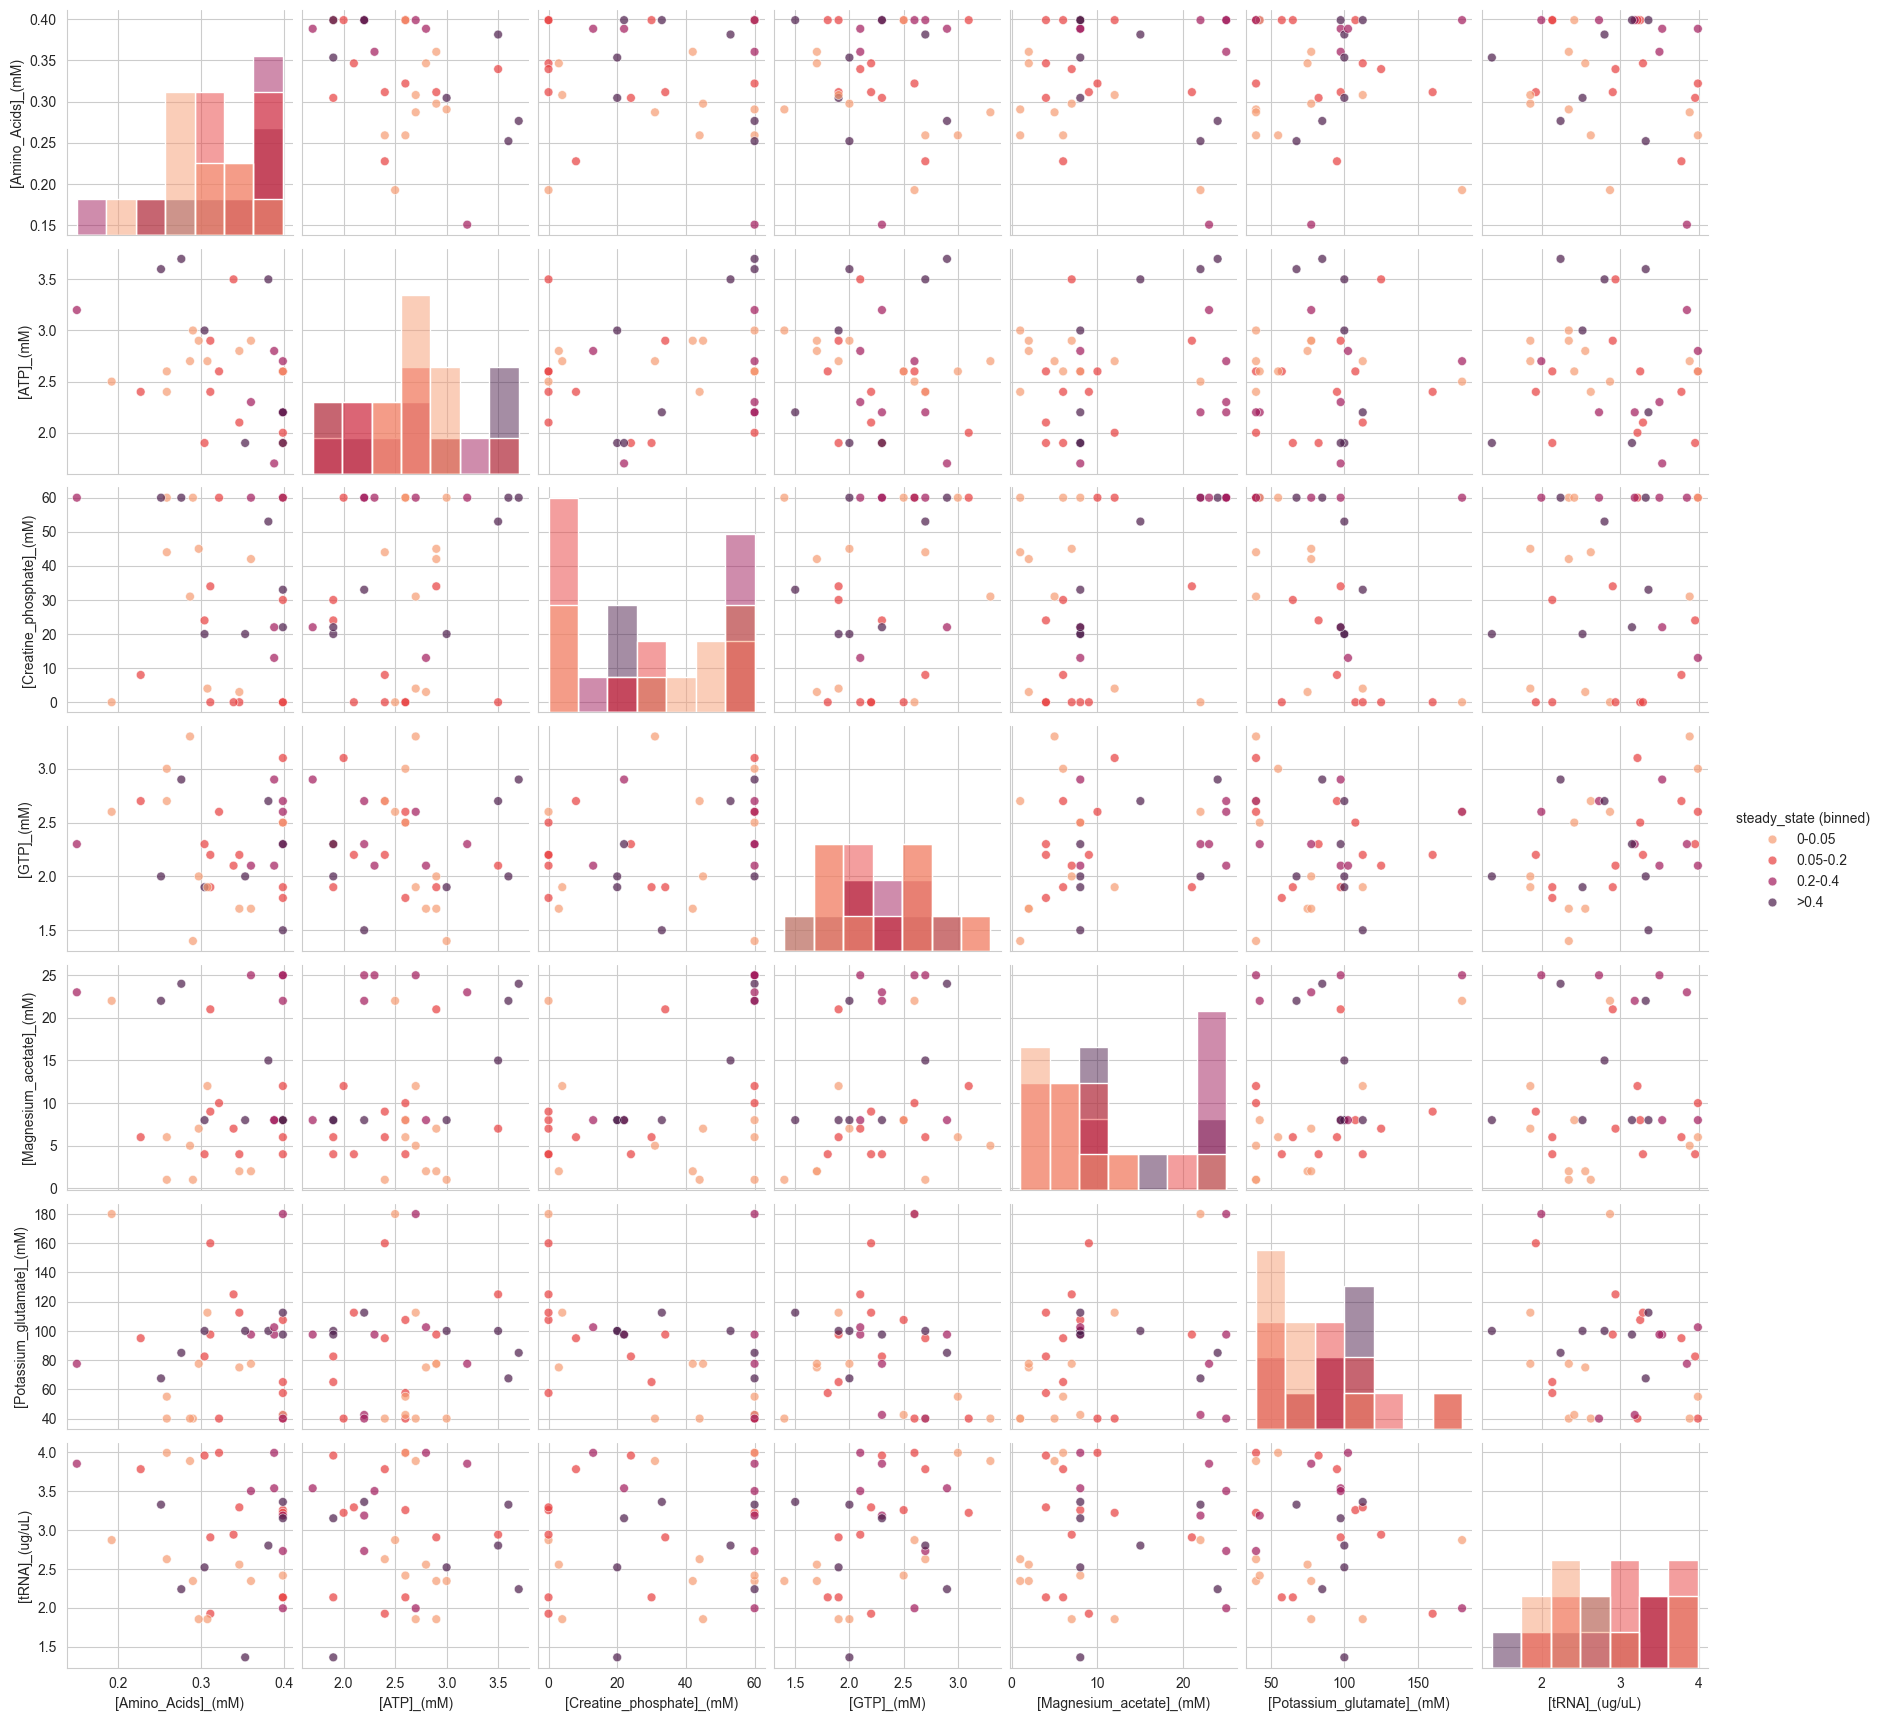

In [32]:
import seaborn as sns
kin['steady_state (binned)'] = pd.cut(                                                                                                                                                                                   
  kin['Steady_State_data_normalized'],                                                                                                                                                                        
  bins=[0, 0.05, .2, 0.4, 1.0],
  labels=['0-0.05', '0.05-0.2', '0.2-0.4', '>0.4']
)                                                                                                                                                                                                               
# val = "Steady_State_data_normalized"
val = 'steady_state (binned)'
g = sns.pairplot(
  kin[factors + [val]],
  vars=factors,
  hue=val,
  palette ="rocket_r",
  # palette={'0-0.05': '#d9534f', '0.05-0.2': 'orange', '>0.2': 'blue'},
  plot_kws={'alpha': 0.7, 's': 40},
  diag_kind='hist',
)

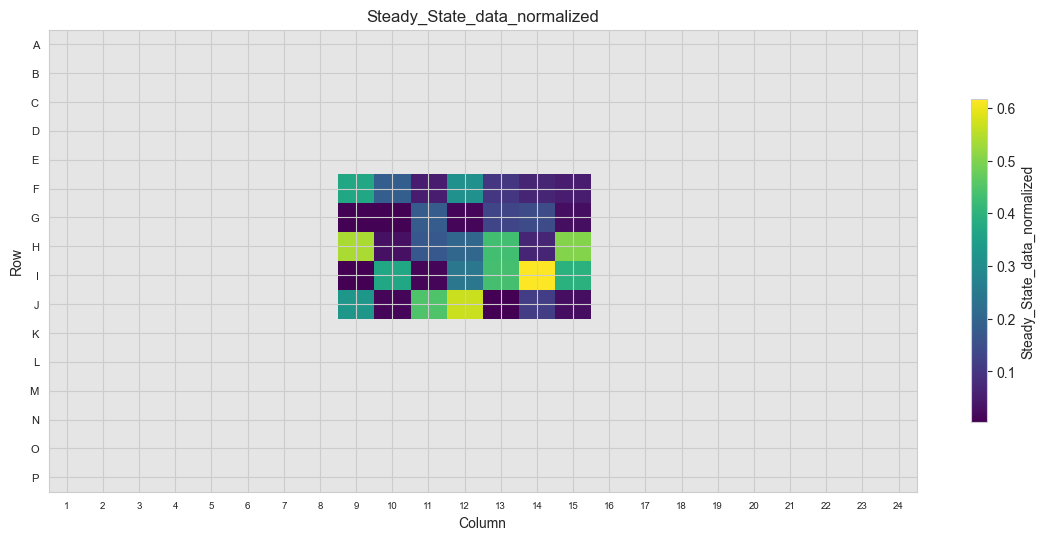

In [33]:
_ = plot_plate_heatmap(kin, "Well", 'Steady_State_data_normalized')

In [34]:
kin.head()

,Well,[Amino_Acids]_(mM),[ATP]_(mM),[Creatine_phosphate]_(mM),[GTP]_(mM),[Magnesium_acetate]_(mM),[Potassium_glutamate]_(mM),[tRNA]_(ug/uL),Velocity_Time,Velocity_data_normalized,Velocity_Max,Lag_Time,Lag_data_normalized,Steady_State_Time,Steady_State_data_normalized,Fit_params,Fit_R^2,Fit_drift,Fit_good_fit,steady_state (binned)
0,F9,0.39,1.70,22.00,2.90,8.00,97.50,3.54,0 days 00:57:42.635813677,0.20,0.21,0 days 00:01:16.396357515,-0.01,0 days 02:20:47.923536436,0.37,"[0.3911673558071128, 2.126252468159096, 0.9618...",0.99,0.01,True,0.2-0.4
1,F10,0.31,2.90,34.00,1.90,21.00,97.50,2.90,0 days 01:02:50.784746528,0.10,0.11,0 days 00:09:17.193404538,-0.00,0 days 02:21:41.896550980,0.19,"[0.1964034979047539, 2.2404840052641704, 1.047...",1.00,0.01,True,0.05-0.2
2,F11,0.32,2.60,60.00,2.60,10.00,40.00,3.99,0 days 00:39:43.360498972,0.03,0.05,0 days 00:08:31.688212801,-0.00,0 days 01:25:38.872915356,0.05,"[0.05452717381062538, 3.846827276835713, 0.662...",0.99,0.00,True,0.05-0.2
3,F12,0.36,2.30,60.00,2.10,25.00,97.50,3.50,0 days 01:05:14.263351818,0.17,0.15,-1 days +23:59:46.779135965,-0.02,0 days 02:41:36.382158222,0.31,"[0.33039158548490144, 1.8332346117229594, 1.08...",1.00,0.01,True,0.2-0.4
4,F13,0.40,2.60,0.00,2.50,8.00,107.50,3.25,0 days 01:00:00.739639846,0.05,0.08,0 days 00:22:47.488211961,0.01,0 days 01:54:48.575915874,0.10,"[0.10447664877248576, 3.223998835432102, 1.000...",1.00,0.00,True,0.05-0.2


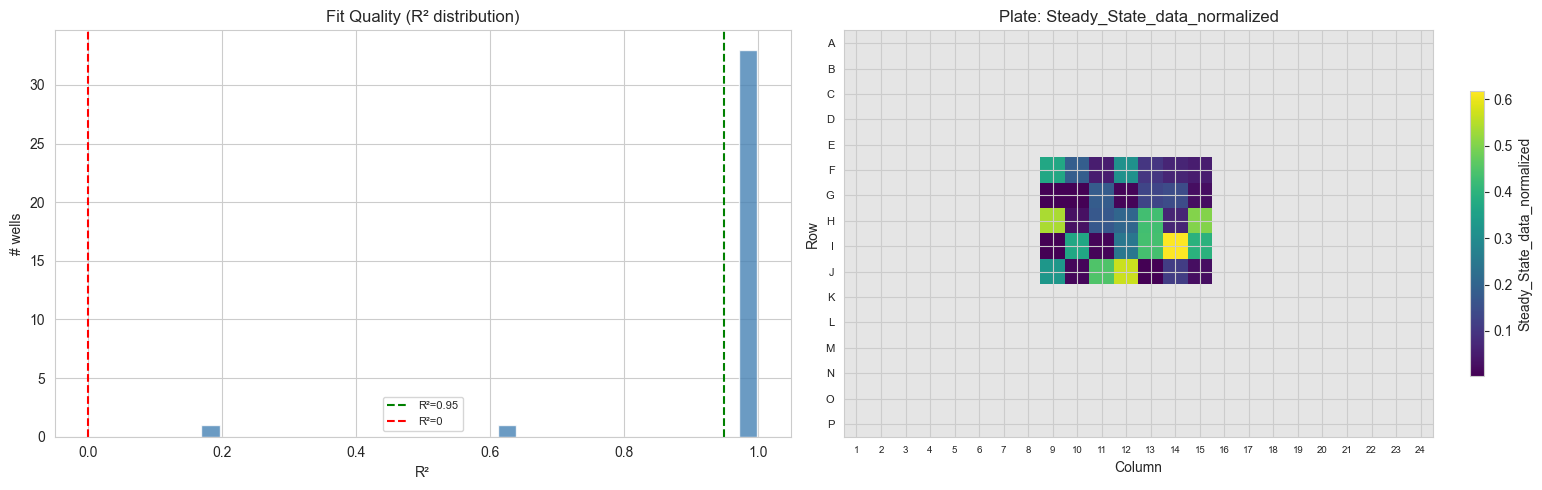

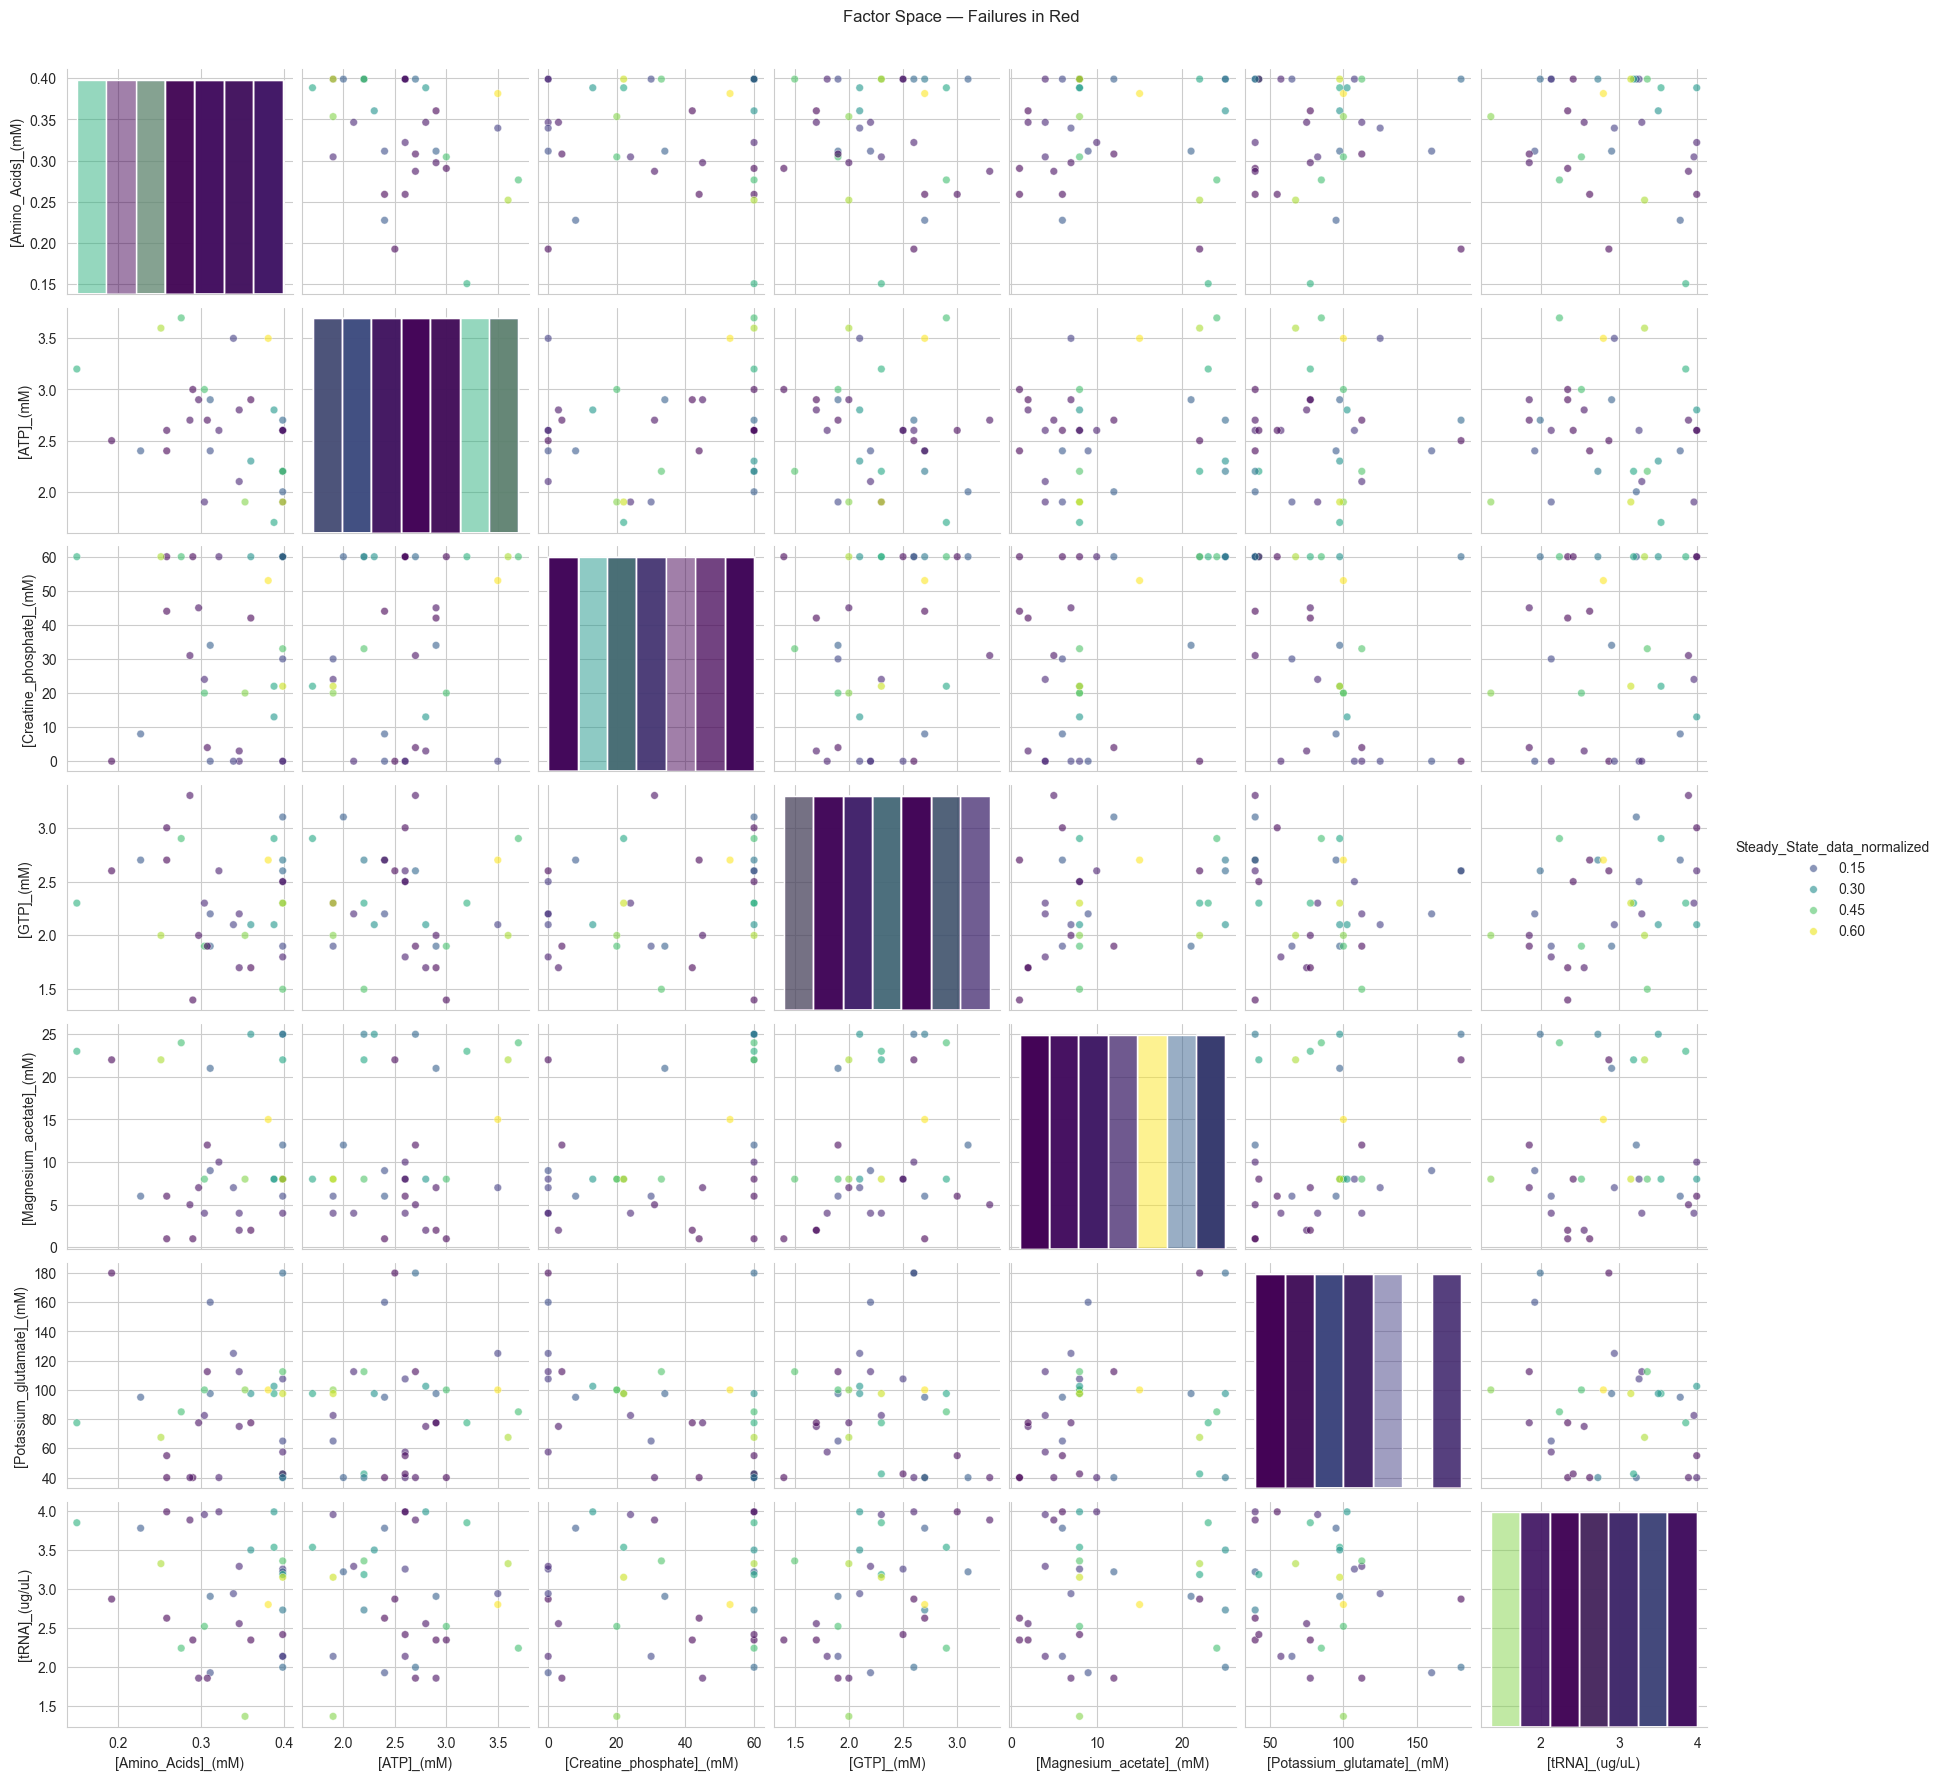

In [35]:
_ = plot_qc_overview(kin, factors, responses, good_fit_col = "Steady_State_data_normalized" )

In [36]:
kin["row"] = kin['Well'].apply(lambda x: x[0])
kin["col"] = kin['Well'].apply(lambda x: int(x[1:]))
kin.head()

,Well,[Amino_Acids]_(mM),[ATP]_(mM),[Creatine_phosphate]_(mM),[GTP]_(mM),[Magnesium_acetate]_(mM),[Potassium_glutamate]_(mM),[tRNA]_(ug/uL),Velocity_Time,Velocity_data_normalized,...,Lag_data_normalized,Steady_State_Time,Steady_State_data_normalized,Fit_params,Fit_R^2,Fit_drift,Fit_good_fit,steady_state (binned),row,col
0,F9,0.39,1.70,22.00,2.90,8.00,97.50,3.54,0 days 00:57:42.635813677,0.20,...,-0.01,0 days 02:20:47.923536436,0.37,"[0.3911673558071128, 2.126252468159096, 0.9618...",0.99,0.01,True,0.2-0.4,F,9
1,F10,0.31,2.90,34.00,1.90,21.00,97.50,2.90,0 days 01:02:50.784746528,0.10,...,-0.00,0 days 02:21:41.896550980,0.19,"[0.1964034979047539, 2.2404840052641704, 1.047...",1.00,0.01,True,0.05-0.2,F,10
2,F11,0.32,2.60,60.00,2.60,10.00,40.00,3.99,0 days 00:39:43.360498972,0.03,...,-0.00,0 days 01:25:38.872915356,0.05,"[0.05452717381062538, 3.846827276835713, 0.662...",0.99,0.00,True,0.05-0.2,F,11
3,F12,0.36,2.30,60.00,2.10,25.00,97.50,3.50,0 days 01:05:14.263351818,0.17,...,-0.02,0 days 02:41:36.382158222,0.31,"[0.33039158548490144, 1.8332346117229594, 1.08...",1.00,0.01,True,0.2-0.4,F,12
4,F13,0.40,2.60,0.00,2.50,8.00,107.50,3.25,0 days 01:00:00.739639846,0.05,...,0.01,0 days 01:54:48.575915874,0.10,"[0.10447664877248576, 3.223998835432102, 1.000...",1.00,0.00,True,0.05-0.2,F,13


In [ ]:
# plot all well signals by dispensing order, not by condition. 
import numpy as np
kin["row_i"] = kin["row"].apply(lambda x: ord(x) - ord("A"))
max_col = kin["col"].max()

# snaker ordering
kin["snake_col"] = np.where(
    kin["row_i"] % 2 == 0,      # even rows: A, C, E...
    kin["col"],                 # normal order
    max_col + 1 - kin["col"]    # reversed order
)
kin["dispense_order"] = kin["row_i"] * max_col + kin["snake_col"]
df_sorted = kin.sort_values("dispense_order")
sns.scatterplot(data=df_sorted, x="dispense_order", y="Steady_State_data_normalized")
# list(df_sorted.dispense_order)

In [35]:
response_col = 'Steady_State_data_normalized'
top_n = 20

top = (
  kin[kin.Fit_good_fit == True]
  .sort_values(response_col, ascending=False)
  .head(top_n)
  [['Well', response_col, 'Velocity_Max'] + factors]
)
print(top.to_string())


   Well  Steady_State_data_normalized  Velocity_Max  [Amino_Acids]_(mM)  [ATP]_(mM)  [Creatine_phosphate]_(mM)  [GTP]_(mM)  [Magnesium_acetate]_(mM)  [Potassium_glutamate]_(mM)  [tRNA]_(ug/uL)
26  I14                          0.62          0.31                0.38        3.50                      53.00        2.70                     15.00                      100.00            2.80
31  J12                          0.57          0.30                0.40        1.90                      22.00        2.30                      8.00                       97.50            3.15
14   H9                          0.54          0.21                0.25        3.60                      60.00        2.00                     22.00                       67.50            3.33
20  H15                          0.50          0.28                0.35        1.90                      20.00        2.00                      8.00                      100.00            1.36
30  J11                          0.

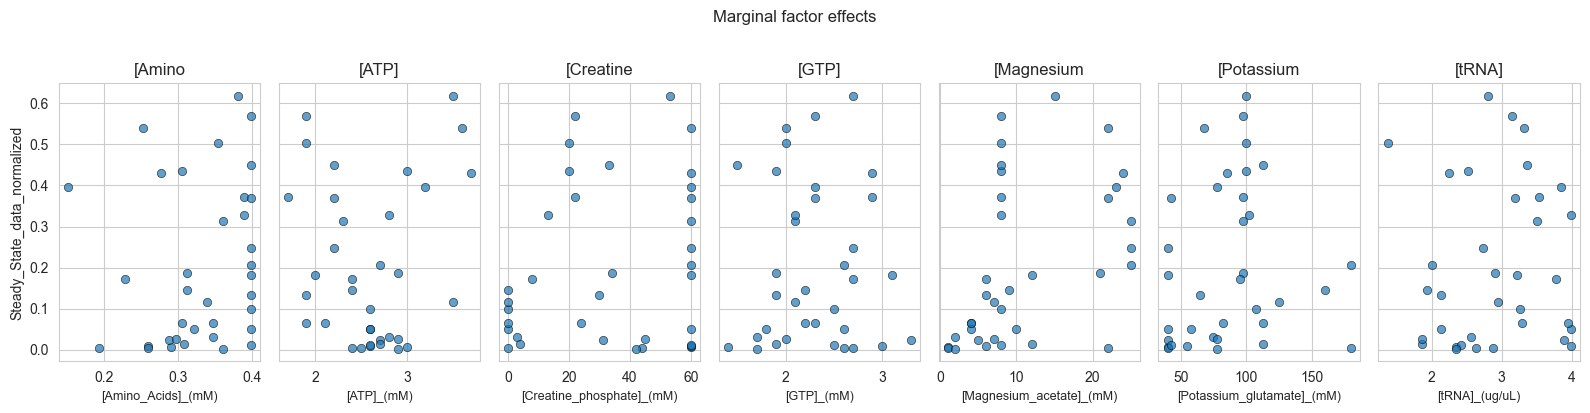

In [36]:
fig, axes = plt.subplots(1, len(factors), figsize=(16, 4), sharey=True)

for ax, f in zip(axes, factors):
  good = kin#[kin.Fit_good_fit == True]
  ax.scatter(good[f], good[response_col], alpha=0.7, edgecolors='k', linewidth=0.5)
  # Trend line
  # z = np.polyfit(good[f], good[response_col], 1)
  x_line = np.linspace(good[f].min(), good[f].max(), 50)
  # ax.plot(x_line, np.polyval(z, x_line), 'r--', linewidth=1.5)
  ax.set_xlabel(f, fontsize=9)
  ax.set_ylabel(response_col if f == factors[0] else '')
  ax.set_title(f.split('_')[0])

fig.suptitle("Marginal factor effects", y=1.02)
plt.tight_layout()


In [37]:
kin.to_csv("kinetic_fits.csv")

In [38]:
factors

['[Amino_Acids]_(mM)',
 '[ATP]_(mM)',
 '[Creatine_phosphate]_(mM)',
 '[GTP]_(mM)',
 '[Magnesium_acetate]_(mM)',
 '[Potassium_glutamate]_(mM)',
 '[tRNA]_(ug/uL)']

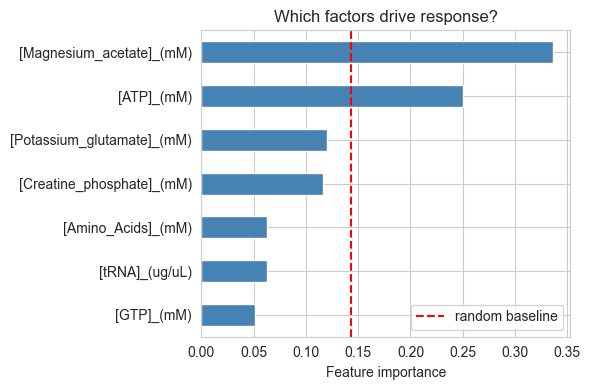

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

good = kin.dropna(subset=factors + [response_col])
X = good[factors].values
y = good[response_col].values

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=factors).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
imp.plot.barh(ax=ax, color='steelblue')
ax.axvline(1/len(factors), color='red', linestyle='--', label='random baseline')
ax.set_xlabel("Feature importance")
ax.set_title("Which factors drive response?")
ax.legend()
plt.tight_layout()


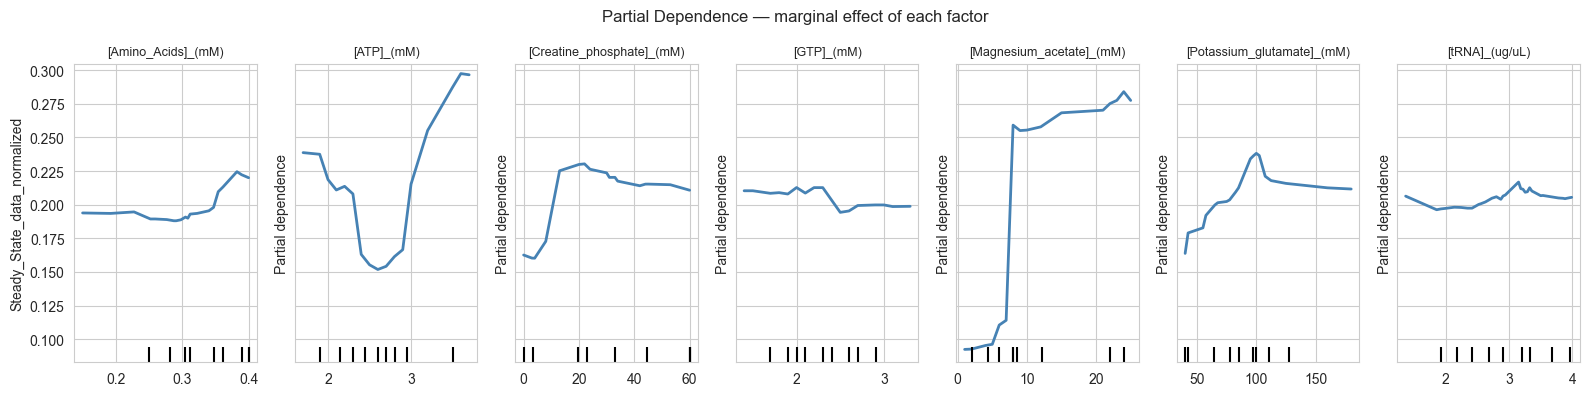

In [40]:
from sklearn.inspection import PartialDependenceDisplay
fig, axes = plt.subplots(1, len(factors), figsize=(16, 4), sharey=True)
PartialDependenceDisplay.from_estimator(
  rf, X,
  features=list(range(len(factors))),
  feature_names=factors,
  ax=axes,
  line_kw={'color': 'steelblue', 'linewidth': 2},
)
for ax, f in zip(axes, factors):
  ax.set_title(f, fontsize=9)
  ax.set_xlabel('')
axes[0].set_ylabel(response_col)
fig.suptitle("Partial Dependence — marginal effect of each factor")
plt.tight_layout()


In [55]:
kin.head()
kin["ATP/GTP ratio"] = kin["[ATP]_(mM)"]/kin["[GTP]_(mM)"]


In [56]:
kin.columns

Index(['Well', '[Amino_Acids]_(mM)', '[ATP]_(mM)', '[Creatine_phosphate]_(mM)',
       '[GTP]_(mM)', '[Magnesium_acetate]_(mM)', '[Potassium_glutamate]_(mM)',
       '[tRNA]_(ug/uL)', 'Velocity_Time', 'Velocity_data_normalized',
       'Velocity_Max', 'Lag_Time', 'Lag_data_normalized', 'Steady_State_Time',
       'Steady_State_data_normalized', 'Fit_params', 'Fit_R^2', 'Fit_drift',
       'Fit_good_fit', 'steady_state (binned)', 'row', 'col', 'row_i',
       'snake_col', 'dispense_order', 'ATP/GTP ratio', 'pareto'],
      dtype='object')

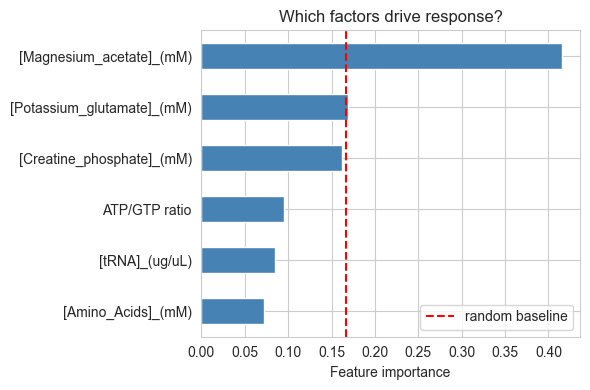

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
cur_factors = ['[Amino_Acids]_(mM)',
 '[Creatine_phosphate]_(mM)',
 '[Magnesium_acetate]_(mM)',
 '[Potassium_glutamate]_(mM)',
 '[tRNA]_(ug/uL)']
cur_factors = cur_factors + ["ATP/GTP ratio"]
good = kin.dropna(subset=cur_factors + [response_col] )
X = good[cur_factors].values
y = good[response_col].values

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=cur_factors).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
imp.plot.barh(ax=ax, color='steelblue')
ax.axvline(1/len(cur_factors), color='red', linestyle='--', label='random baseline')
ax.set_xlabel("Feature importance")
ax.set_title("Which factors drive response?")
ax.legend()
plt.tight_layout()


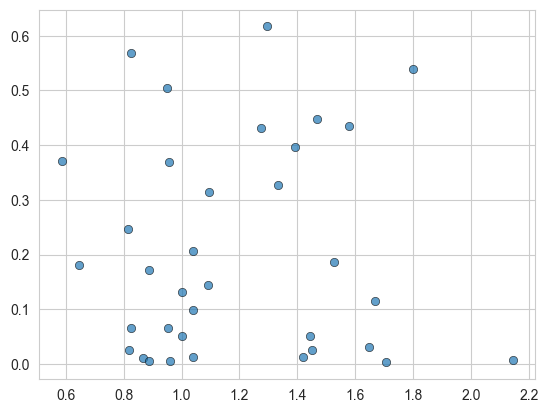

In [53]:
plt.scatter(kin["ATP/GTP ratio"], kin[response_col], alpha=0.7, edgecolors='k', linewidth=0.5)

In [1]:
kin["pareto"] =( kin["[ATP]_(mM)"] + kin["[GTP]_(mM)"] )/ (kin['[Amino_Acids]_(mM)'] + kin['[tRNA]_(ug/uL)'])
sns.scatterplot(kin,x='Steady_State_data_normalized', y='Velocity_Max', hue="pareto", alpha=0.8)
plt.title("(ATP + GTP) / (AAs + tRNAs)")

NameError: name 'kin' is not defined